In [2]:
import pandas as pd
import polars as pl
import numpy as np
import geopandas as gpd
import seaborn as sns
import pyogrio
import os
import folium # For map viz
import matplotlib.pyplot as plt
import duckdb

pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.max_colwidth", None)  # show full width of showing cols
pd.set_option(
    "display.expand_frame_repr", False
)  # print cols side by side as it's supposed to be

# Load Communes Inputs


We load what we believe are meaningful communes socio-economic-risk factors


In [4]:
# ODIS_DUCKDB_FILE = "odis.duckdb"
def open_duckdb():
    PCC_DUCKDB_FILE = "dev.duckdb"

    con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
    con.sql(f"ATTACH '{PCC_DUCKDB_FILE}' AS pcc;")
    return con

def close_duckdb(con):
    con.close()

In [10]:
# Show tables 
con = open_duckdb()
q = """
SHOW TABLES
"""

tables_list = con.sql(q)
close_duckdb(con)

In [89]:
tables_list=tables_list.df()
tables_list.head(20)

,name
0,azi_gaspar
1,bronze_rei
2,budget_communes
3,budget_per_compte_communes
4,catnat_gaspar
5,ccr_details
6,ccr_main_page
7,datactivist_commune
8,dicrim_gaspar
9,geoportail_ccr_communes


# Load Communes output


For this analysis we will consider that the increase in insurance cost (Nul, Moderate, High, Very High) is the outcome we want to predict.


In [5]:
con = open_duckdb()
q = """
SELECT *
FROM dev.main.primes_assurances_communes
--LIMIT 10000
"""
q  = con.sql(q)
primes_com = q.df()
primes_com.head()
close_duckdb(con)


In [6]:
# We keep only the 6161 Multirisques insurance cost (6168 is for « Autres assurances » )
primes_com = primes_com[primes_com.compte == 6161]
primes_com = primes_com[primes_com.code_insee != 'emp']

# Cleaning up the code_geo column to join
primes_com['code_departement'] = primes_com['code_departement'].str.replace('0', '').str.zfill(2)
primes_com['code_insee'] = primes_com.apply(
    lambda x: str(x['code_insee']).zfill(3) if len(x['code_departement']) == 2 else str(x['code_insee']).zfill(2),
    axis=1
)
primes_com['code_geo'] = primes_com['code_departement'] + primes_com['code_insee']
primes_com.head()

,code_departement,code_insee,siret,siren,annee,code_region,compte,code_geo,code_geo_from_siren,nom_com,solde_debiteur,solde_crediteur,solde
0,79,018,21790018200015,18,2022,75,6161,79018,None,None,4113.20,0.0,4113.20
2,76,668,21760668000015,668,2022,28,6161,76668,None,None,3386.09,0.0,3386.09
3,72,050,21720050000015,50,2022,52,6161,72050,None,None,13752.50,0.0,13752.50
4,82,182,21820182000014,182,2022,76,6161,82182,None,None,6098.59,0.0,6098.59
8,35,166,21350166100010,166,2022,53,6161,35166,None,None,5771.22,0.0,5771.22


In [7]:
# We want to flatten the dataframe to get all years in a single row
annees_dispo = sorted(primes_com.annee.unique().tolist())

# We pick all the communes that still existed in 2024 as a base
primes_com_flat = primes_com[primes_com.annee == max(annees_dispo)][['siret', 'code_geo']] 

# We self join for each year
for year in annees_dispo:
    if year >= 2016: # It seems we don't have data for the communes before 2016 (at least not based on siret)
        primes_com_flat = primes_com_flat.merge(primes_com[primes_com.annee == year][['siret', 'solde_debiteur']], on='siret', how='left').rename(columns={'solde_debiteur': f'primes_{year}'})

# primes_com_flat['evol_17-24'] = (primes_com_flat['primes_2024'] - primes_com_flat['primes_2017'])/(primes_com_flat['primes_2017'])
primes_com_flat.head(20)

,siret,code_geo,primes_2016,primes_2017,primes_2018,primes_2019,primes_2020,primes_2021,primes_2022,primes_2023,primes_2024
0,21540162100010,54162,18259.81,16675.39,17610.53,17244.53,13361.04,11075.46,11474.30,3153.80,8010.03
1,21540180300014,54180,1797.41,1826.71,1890.62,1784.05,1810.45,1897.35,1951.17,2931.84,3115.76
2,21540199300013,54199,6340.47,6622.36,7027.54,4620.87,4828.60,5190.88,5106.21,5910.81,6332.66
3,21830128100018,83128,20144.03,10208.97,10528.83,5543.91,10900.56,10902.91,11232.69,13173.69,21145.96
4,21830129900010,83129,200679.92,207996.57,175580.68,190254.49,167377.58,137982.80,159647.67,185749.05,298909.51
5,21830136400012,83136,19946.25,13128.14,45632.51,40100.19,12327.62,14383.31,15951.83,19858.27,27043.94
6,21540299100016,54299,3642.70,3593.96,4253.88,3738.18,3755.61,3795.26,4028.44,4539.96,4659.78
7,21540302300017,54302,4369.62,4464.88,4577.42,4733.23,4908.37,5356.72,5520.56,7055.13,8828.95
8,21800666600018,08707,612.40,627.50,633.69,643.26,658.90,661.67,680.09,672.00,725.04
9,21800670800018,08711,15236.29,19279.55,17172.14,15325.01,16634.96,17305.45,17848.21,18080.98,22410.99


In [8]:
primes_com_flat.describe()

,primes_2016,primes_2017,primes_2018,primes_2019,primes_2020,primes_2021,primes_2022,primes_2023,primes_2024
count,3.083600e+04,3.127400e+04,3.162100e+04,2.768000e+04,3.223000e+04,3.236300e+04,3.249700e+04,3.270500e+04,3.313500e+04
mean,1.287201e+04,1.256794e+04,1.208275e+04,1.188624e+04,1.168870e+04,1.193294e+04,1.242350e+04,1.370430e+04,1.620518e+04
std,4.485301e+04,4.291681e+04,3.991647e+04,3.824516e+04,3.632497e+04,3.871012e+04,4.011433e+04,4.412690e+04,5.496220e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.548170e+03,2.550858e+03,2.562170e+03,2.563162e+03,2.604800e+03,2.620945e+03,2.678330e+03,2.864930e+03,3.075595e+03
50%,4.759420e+03,4.762245e+03,4.727230e+03,4.725055e+03,4.784970e+03,4.817060e+03,4.907410e+03,5.285210e+03,5.761760e+03
75%,9.768805e+03,9.730520e+03,9.620460e+03,9.690120e+03,9.733750e+03,9.823770e+03,1.003100e+04,1.097197e+04,1.217880e+04
max,1.895562e+06,1.800383e+06,1.875344e+06,1.934643e+06,1.951847e+06,1.984672e+06,1.566014e+06,1.668078e+06,2.299777e+06


In [9]:
primes_com_flat.to_parquet('../csv/primes_com_flat.parquet')

In [8]:
primes_col = [c for c in primes_com_flat.columns if c.startswith('primes_')]

primes_com_flat['year_max_idx'] = np.nanargmax(primes_com_flat[primes_col], axis=1) # We get the index of the max value ignoring NaNs
primes_com_flat['year_primes_max'] = primes_com_flat[primes_col].max(axis=1)

primes_com_flat['year_min_idx'] = np.nanargmin(primes_com_flat[primes_col], axis=1)
primes_com_flat['year_primes_min'] = primes_com_flat[primes_col].min(axis=1)

primes_com_flat['year_primes_evol_ratio'] = np.sign(primes_com_flat['year_max_idx'] - primes_com_flat['year_min_idx']) * (primes_com_flat['year_primes_max'] - primes_com_flat['year_primes_min'])/primes_com_flat['year_primes_max']

primes_com_flat.head()

,siret,code_geo,primes_2016,primes_2017,primes_2018,primes_2019,primes_2020,primes_2021,primes_2022,primes_2023,primes_2024,year_max_idx,year_primes_max,year_min_idx,year_primes_min,year_primes_evol_ratio
0,21540162100010,54162,18259.81,16675.39,17610.53,17244.53,13361.04,11075.46,11474.30,3153.80,8010.03,0,18259.81,7,3153.80,-0.827282
1,21540180300014,54180,1797.41,1826.71,1890.62,1784.05,1810.45,1897.35,1951.17,2931.84,3115.76,8,3115.76,3,1784.05,0.427411
2,21540199300013,54199,6340.47,6622.36,7027.54,4620.87,4828.60,5190.88,5106.21,5910.81,6332.66,2,7027.54,3,4620.87,-0.342463
3,21830128100018,83128,20144.03,10208.97,10528.83,5543.91,10900.56,10902.91,11232.69,13173.69,21145.96,8,21145.96,3,5543.91,0.737827
4,21830129900010,83129,200679.92,207996.57,175580.68,190254.49,167377.58,137982.80,159647.67,185749.05,298909.51,8,298909.51,5,137982.80,0.538379


In [9]:
primes_com_flat.sort_values('year_primes_evol_ratio', ascending=True).head(20)

,siret,code_geo,primes_2016,primes_2017,primes_2018,primes_2019,primes_2020,primes_2021,primes_2022,primes_2023,primes_2024,year_max_idx,year_primes_max,year_min_idx,year_primes_min,year_primes_evol_ratio
517,21640016800011,64016,9953.95,9686.51,20662.18,0.00,9945.31,15299.37,8499.57,9092.89,9722.66,2,20662.18,3,0.0,-1.0
19176,21500577800018,05577,NaN,3962.97,3733.80,3779.31,3958.58,3628.13,2938.48,3254.19,0.00,1,3962.97,8,0.0,-1.0
7967,21370072700018,37072,92903.39,57377.97,40649.89,43520.24,12330.84,23954.01,0.00,12868.37,7213.87,0,92903.39,6,0.0,-1.0
29053,21700078500014,07078,1822.82,3724.73,0.00,NaN,1954.02,2006.28,2126.78,2423.19,2554.08,1,3724.73,2,0.0,-1.0
17964,21220293100011,22293,5757.94,6588.40,6936.08,5061.84,8801.30,0.00,6574.87,3950.43,4793.07,4,8801.30,5,0.0,-1.0
25268,21330189800010,33189,9539.43,9764.94,9906.45,3345.00,3500.98,7145.35,0.00,4994.84,5437.05,2,9906.45,6,0.0,-1.0
14512,21160340200010,16340,5653.77,5764.51,5781.49,7267.54,6914.31,0.00,NaN,NaN,6175.97,3,7267.54,5,0.0,-1.0
30097,21200066500019,02066,110.45,113.56,124.22,182.24,316.15,3888.93,0.00,114.51,1992.30,5,3888.93,6,0.0,-1.0
2303,21590241200018,59241,7725.49,3327.48,7110.89,14067.65,0.00,4094.87,4498.63,4691.44,4949.37,3,14067.65,4,0.0,-1.0
7557,21240541900012,24541,3226.93,3411.72,3529.68,7207.43,405.72,4143.77,3724.34,0.00,4233.58,3,7207.43,7,0.0,-1.0


In [64]:
primes_com_clean = primes_com_flat[(primes_com_flat.year_primes_min >= 0)] # We filter out cases where the minimum year of prime is null (possibly a reporting error)

In [68]:
primes_com_clean[primes_com_clean.year_primes_evol_ratio <= -0.9]

,siret,code_geo,primes_2016,primes_2017,primes_2018,primes_2019,primes_2020,primes_2021,primes_2022,primes_2023,primes_2024,year_max_idx,year_primes_max,year_min_idx,year_primes_min,year_primes_evol_ratio
222,21570014700014,57014,5647.79,3151.46,2813.34,354.05,2884.62,2958.53,3104.77,3494.55,3860.35,0,5647.79,3,354.05,-0.937312
238,21010296800018,01296,6731.58,4972.53,5137.58,NaN,5778.98,6006.26,453.20,5966.88,6440.03,0,6731.58,6,453.20,-0.932676
241,21390149900011,39149,11818.26,NaN,5310.33,6195.81,5999.62,484.25,496.93,7682.53,8200.27,0,11818.26,5,484.25,-0.959025
317,20008346700015,06245,NaN,NaN,NaN,21456.00,43795.83,2240.88,24803.81,25041.11,31457.52,4,43795.83,5,2240.88,-0.948833
347,21840016600011,84016,29721.88,46027.50,45802.51,187288.81,7429.28,6261.09,2104.36,1934.75,2976.21,3,187288.81,7,1934.75,-0.989670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32881,21250594500015,25594,2354.14,2360.42,2432.36,2495.09,2676.08,5540.21,49.81,3280.34,3388.00,5,5540.21,6,49.81,-0.991009
32920,21170290700018,17290,3962.00,3933.00,4047.00,4180.00,4293.00,4518.00,4844.00,3820.00,275.00,6,4844.00,8,275.00,-0.943229
32952,21160189300012,16189,3175.00,3619.75,3073.00,3177.00,2999.83,2830.00,NaN,5849.83,575.25,7,5849.83,8,575.25,-0.901664
32988,21310053000012,31053,11184.99,11413.33,11703.27,9147.10,9460.09,9608.94,10000.94,10923.62,67.65,2,11703.27,8,67.65,-0.994220


array([[<Axes: title={'center': 'year_primes_evol_ratio'}>]], dtype=object)

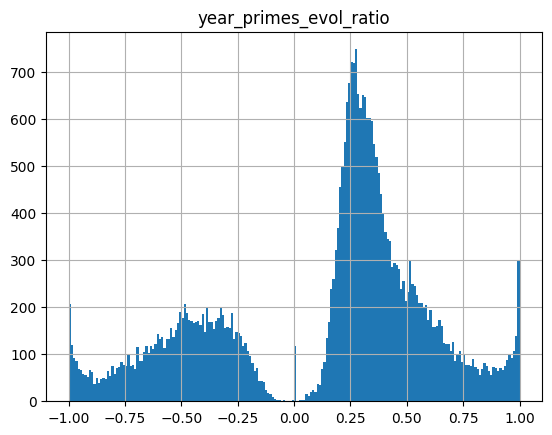

In [67]:
primes_com_clean.hist('year_primes_evol_ratio', bins=200)

array([[<Axes: title={'center': 'primes_evol'}>]], dtype=object)

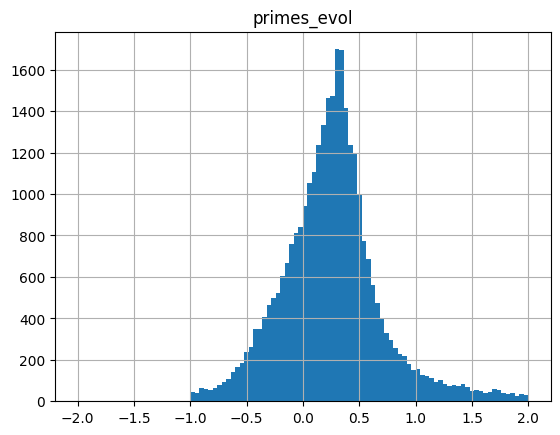

In [60]:
# Paying less that 100 Euros seems unealistic so let's filter those out
primes_com_clean = primes_com_flat[(primes_com_flat.montant_primes_2017 >= 100) & (primes_com_flat.montant_primes_2024 >= 100)]
primes_com_clean.hist('primes_evol', bins=100, range=(-2,2))


In [62]:
primes_com_clean.sort_values('primes_evol', ascending=True).head(20)

,siret,code_departement,code_insee,montant_primes_2017,montant_primes_2024,primes_evol,code_geo
8000,21130067800011,13,067,30409.96,175.00,-0.994245,13067
525,21890025600015,89,025,39587.81,255.60,-0.993543,89025
30696,21910649900011,91,649,33995.03,254.38,-0.992517,91649
25815,21440036800012,44,036,28886.40,292.66,-0.989869,44036
27251,21580304000017,58,304,30889.85,339.70,-0.989003,58304
2364,21650138700015,65,138,100504.64,1385.36,-0.986216,65138
21885,21770113500014,77,113,9719.50,143.82,-0.985203,77113
17706,21650017300010,65,017,14609.56,223.91,-0.984674,65017
31252,21950541900016,95,541,19385.97,298.23,-0.984616,95541
25355,21590654600019,59,654,27236.30,420.91,-0.984546,59654


In [67]:
primes_com[primes_com.siret == 21440036800012].sort_values('annee')

,annee,siret,code_departement,code_insee,code_region,compte,solde_debiteur,solde_crediteur,code_geo
533957,2016,21440036800012,044,36,52,6161,27519.49,0.0,04436
481082,2017,21440036800012,044,36,52,6161,28886.40,0.0,04436
234630,2018,21440036800012,044,36,52,6161,21447.23,0.0,04436
324934,2019,21440036800012,044,36,52,6161,26552.78,0.0,04436
64892,2020,21440036800012,044,36,52,6161,25530.04,0.0,04436
47283,2021,21440036800012,044,36,52,6161,26937.07,0.0,04436
119772,2022,21440036800012,044,36,52,6161,28394.02,0.0,04436
200975,2023,21440036800012,044,36,52,6161,228.97,0.0,04436
306235,2024,21440036800012,044,36,52,6161,292.66,0.0,04436


In [ ]:
print(primes_com_clean[primes_com_clean.primes_evol <=0].shape[0] / primes_com_clean.shape[0])
print(primes_com_clean[primes_com_clean.primes_evol >0].shape[0] / primes_com_clean.shape[0])

0.24450037285607756
0.7554996271439225


# Decision Tree Classification


What are we trying to do:

- We want to predict the risk level for commune to face


In [74]:
primes_com_pos = primes_com_clean[primes_com_clean.primes_evol >=0]

array([[<Axes: title={'center': 'primes_evol'}>]], dtype=object)

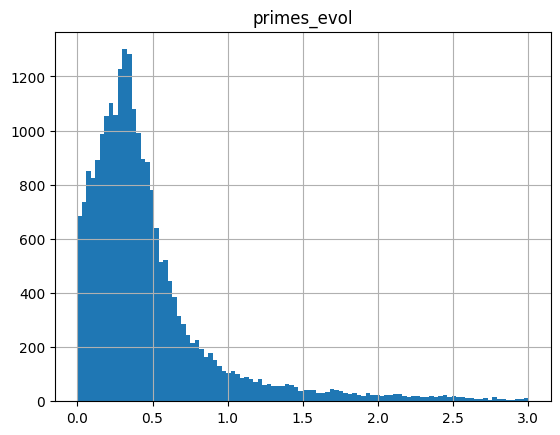

In [77]:
primes_com_pos.hist('primes_evol', bins=100, range=(0,3))

In [18]:
# Identification of "Step Function" drop in insurance premiums
import numpy as np
import pandas as pd

# We focus on the available years 2017 to 2024
# We use primes_com_flat because primes_com_clean might filter out communes 
# that have very low or 0 premiums in 2024 (which are the ones we want to find!)

years = list(range(2017, 2025))
years_cols = [f'primes_{year}' for year in years]

def find_step_drop(row):
    """
    Detects if there is a sharp and persistent drop (> 90%) in the time series.
    Returns: Series with has_drop, drop_year, drop_pct
    """
    vals = row[years_cols].values.astype(float)
    
    # Needs to have valid data initially to consider it a drop
    if np.isnan(vals[0]) or vals[0] == 0:
        return pd.Series({'has_drop': False, 'drop_year': None, 'drop_pct': None})
        
    best_drop_year = None
    best_drop_pct = 0
    has_drop = False
    
    # Test possible split years 
    for i in range(1, len(vals)):
        before = vals[:i]
        after = vals[i:]
        
        # We fill NaNs with 0 because we assume missing = not paying
        before_clean = np.nan_to_num(before, nan=0.0)
        after_clean = np.nan_to_num(after, nan=0.0)
        
        mean_before = np.mean(before_clean)
        mean_after = np.mean(after_clean)
        
        # Ensure they were actually paying something substantial before
        if mean_before > 100: 
            # Check for a 90% drop
            if mean_after <= 0.2 * mean_before:
                # Persistent check: make sure there is no random huge spike back up
                if np.max(after_clean) <= 0.2 * mean_before:
                    drop_pct = (mean_before - mean_after) / mean_before
                    if drop_pct > best_drop_pct:
                        best_drop_pct = drop_pct
                        best_drop_year = years[i]
                        has_drop = True

    return pd.Series({'has_drop': has_drop, 'drop_year': best_drop_year, 'drop_pct': best_drop_pct})

# Apply the logic
print("Running detection logic...")
drop_info = primes_com_flat.apply(find_step_drop, axis=1)

# Combine with original data
df_analysis = pd.concat([primes_com_flat, drop_info], axis=1)

# Filter the results and format
df_drops = df_analysis[df_analysis['has_drop']].copy()
df_drops['drop_pct_str'] = (df_drops['drop_pct'] * 100).round(1).astype(str) + '%'

df_drops = df_drops[['siret', 'code_geo', 'drop_year', 'drop_pct', 'drop_pct_str'] + years_cols].sort_values('drop_pct', ascending=False)

print(f"Found {len(df_drops)} communes with a step-function drop.")
df_drops.head(20)

Running detection logic...
Found 260 communes with a step-function drop.


,siret,code_geo,drop_year,drop_pct,drop_pct_str,primes_2017,primes_2018,primes_2019,primes_2020,primes_2021,primes_2022,primes_2023,primes_2024
19176,21500577800018,05577,2024.0,1.000000,100.0%,3962.97,3733.80,3779.31,3958.58,3628.13,2938.48,3254.19,0.00
7532,21250225600010,25225,2024.0,1.000000,100.0%,1830.40,1856.10,1884.14,1892.59,1949.17,2042.48,4688.50,0.00
4402,21570177200018,57177,2024.0,1.000000,100.0%,14172.49,14380.32,10357.94,11083.78,9481.70,10334.99,16037.13,0.00
4498,21830146300012,83146,2024.0,1.000000,100.0%,9419.48,12422.29,11871.16,11855.88,12986.15,10263.23,16126.66,0.00
27657,21360074500011,36074,2024.0,1.000000,100.0%,11629.82,10779.95,11220.14,11643.87,9618.21,4106.30,4891.70,0.00
472,21700423300011,07423,2024.0,0.999972,100.0%,2727.01,2562.42,2383.44,2459.44,2273.03,2381.99,2700.47,0.07
3730,21370268100015,37268,2024.0,0.998626,99.9%,3609.92,3649.07,3704.74,6055.45,3072.16,3159.87,3946.00,5.34
1873,21250633100017,25633,2024.0,0.997874,99.8%,10051.78,NaN,NaN,5186.14,5545.14,6129.08,14776.51,12.66
10055,21510038900018,51043,2024.0,0.997415,99.7%,17588.38,18373.85,18217.98,21642.57,21838.62,22586.55,15644.43,50.18
11496,21010382600017,01382,2024.0,0.997150,99.7%,1746.93,2940.16,1499.26,1499.26,1499.26,1608.40,2150.18,5.27


In [75]:
q = """
SELECT *
FROM dev.main.budget_communes
--LIMIT 10000
"""
q  = con.sql(q)
budget_com = q.df()
budget_com.head()

,annee,code_geo,siret_budget,libelle_budget,type_budget,montant
0,2017,69175,21690175100018,SAVIGNY,Budget principal,319673.98
1,2017,69175,21690175100059,LOC COM SAVIGNY,Budget annexe,16791.97
2,2017,69176,21690176900010,SOUCIEU-EN-JARREST,Budget principal,517111.78
3,2017,69177,21690177700013,SOURCIEUX-LES-MINES,Budget principal,268090.53
4,2017,69178,21690178500016,SOUZY,Budget principal,135733.30


In [90]:
q = """
SELECT *
FROM dev.main.insee_commune
--LIMIT 10000
"""
q  = con.sql(q)
com = q.df()
com.head()

,type_com,com,reg,dep,ctcd,arr,tncc,ncc,nccenr,libelle,can,com_parent
0,COM,01001,84,01,01D,012,5,ABERGEMENT CLEMENCIAT,Abergement-Clémenciat,L'Abergement-Clémenciat,0108,NaN
1,COM,01002,84,01,01D,011,5,ABERGEMENT DE VAREY,Abergement-de-Varey,L'Abergement-de-Varey,0101,NaN
2,COM,01004,84,01,01D,011,1,AMBERIEU EN BUGEY,Ambérieu-en-Bugey,Ambérieu-en-Bugey,0101,NaN
3,COM,01005,84,01,01D,012,1,AMBERIEUX EN DOMBES,Ambérieux-en-Dombes,Ambérieux-en-Dombes,0122,NaN
4,COM,01006,84,01,01D,011,1,AMBLEON,Ambléon,Ambléon,0104,NaN


In [11]:
import geopandas as gpd

# TopoJSON files contain nested spatial data that pd.read_json cannot parse directly.
# Using geopandas.read_file handles the TopoJSON structure and CRS (2154) automatically.
com = gpd.read_file('../csv_large/a-com2022-topo-2154.json')
com.head()

/Users/jacques/dev/14_PrixChangementClimatique/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'a-com2022-topo-2154.json': 'a_com2022' (default), 'a_reg2022', 'a_dep2022'. Specify layer parameter to avoid this warning.
  result = read_func(


,id,codgeo,dep,reg,xcl2154,ycl2154,libgeo,geometry
0,None,01001,01,84,848241,6563021,L'Abergement-Clémenciat,"POLYGON ((846981.436 6564107.36, 847017.457 6564658.621, 847161.538 6565159.768, 847247.988 6566119.105, 847673.03 6566670.367, 848206.133 6566562.978, 848573.542 6566555.819, 848818.481 6566677.526, 849077.829 6566670.367, 849553.299 6566076.15, 849661.361 6565854.214, 849459.646 6565274.315, 849121.053 6564959.309, 848998.584 6564501.118, 849027.4 6564322.137, 849452.442 6564300.659, 850100.811 6563778.035, 851123.793 6563369.959, 850741.976 6562833.016, 850324.138 6562940.404, 850194.464 6562868.812, 849870.28 6562396.302, 849711.789 6561773.449, 849827.055 6561000.251, 849632.544 6560463.309, 849452.442 6560255.691, 848732.032 6559611.36, 848422.256 6559639.996, 848379.031 6560112.506, 848256.562 6560370.239, 847399.274 6560613.653, 847298.416 6561050.366, 847384.866 6561358.213, 847745.07 6561880.837, 847867.54 6562281.755, 847651.417 6562560.965, 847514.539 6563097.908, 847067.885 6563720.761, 846822.946 6563785.194, 846981.436 6564107.36))"
1,None,01002,01,84,887495,6548152,L'Abergement-de-Varey,"POLYGON ((886027.651 6548170.9, 886157.325 6548500.225, 886740.857 6549402.288, 887029.021 6549588.429, 887223.532 6549910.594, 887425.246 6550690.951, 887533.308 6550855.613, 887979.962 6550719.588, 888275.33 6550726.747, 888844.454 6550239.919, 888786.821 6549924.913, 888902.087 6549574.11, 889111.006 6549302.059, 889067.781 6548586.136, 888902.087 6548092.148, 888902.087 6547154.288, 888426.616 6545636.53, 888109.636 6545450.39, 887864.697 6545779.715, 887655.778 6545851.307, 887749.431 6546631.664, 887735.023 6547025.422, 887302.777 6547175.766, 886971.388 6547397.702, 886027.651 6548170.9))"
2,None,01004,01,84,882724,6542583,Ambérieu-en-Bugey,"POLYGON ((884889.404 6539629.931, 884795.75 6539615.612, 884118.565 6539944.937, 883736.748 6540381.651, 883470.196 6540889.956, 882735.378 6541376.785, 881942.927 6541591.562, 881337.783 6541441.218, 881100.048 6541806.339, 880819.088 6542006.797, 880293.189 6542214.415, 880235.556 6542321.804, 880422.862 6544025.702, 880430.067 6544498.212, 880927.149 6545364.479, 881654.763 6545235.613, 882367.969 6545292.887, 883297.298 6544648.556, 883664.707 6544333.549, 884622.852 6544405.142, 884903.812 6544763.103, 885148.751 6544899.129, 885559.385 6544999.358, 885523.364 6545278.568, 886286.999 6544899.129, 886459.897 6544863.333, 886834.51 6544985.04, 886827.306 6544283.434, 886474.305 6542686.925, 886611.183 6541706.109, 886589.571 6540882.797, 885962.814 6540940.071, 885638.63 6540768.249, 885242.405 6540360.173, 885076.71 6539859.026, 884889.404 6539629.931))"
3,None,01005,01,84,847277,6545791,Ambérieux-en-Dombes,"POLYGON ((845951.25 6547999.078, 846073.72 6548049.193, 846664.456 6547934.645, 847348.845 6548335.562, 847737.866 6548385.677, 847788.295 6547956.123, 848220.541 6547619.639, 848278.174 6547168.607, 848753.644 6546939.511, 849445.238 6546932.352, 850050.382 6546524.275, 850713.159 6546366.772, 850633.914 6545400.275, 850785.2 6544877.651, 850691.547 6544254.798, 850410.587 6544340.708, 850410.587 6544061.498, 849978.341 6543946.95, 849214.707 6544082.976, 848587.95 6544340.708, 847896.357 6544283.434, 846758.109 6544004.224, 846297.047 6544440.938, 845583.841 6544627.078, 845245.248 6544963.562, 845533.412 6545865.626, 846037.699 6546710.416, 846080.924 6547404.862, 845951.25 6547999.078))"
4,None,01006,01,84,902191,6519791,Ambléon,"POLYGON ((901336.361 6521123.305, 902460.201 6521223.534, 902784.385 6521037.394, 902957.283 6520586.362, 902964.488 6519977.827, 902993.304 6519154.515, 903295.876 6518395.636, 902705.14 6518302.566, 902525.038 6518818.031, 901977.526 6519147.356, 901422.81 6519190.311, 900680.788 6518954.056, 900464.665 6519405.088, 900097.256 6519891.916, 899816.296 6520335.789, 900068.44 6520407.381, 900515.094 6521058.872, 900803.258 6521416.834, 901336.361 6521123.305))"


In [12]:
import pandas as pd
epci = pd.read_json('../csv_large/epci.json').rename(columns={'code': 'code_epci'})
# Convert JSON strings to lists if necessary
epci['membres'] = epci['membres'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

# Explode the list into individual rows
epci_exploded = epci.explode('membres').reset_index(drop=True)

# Expand the dictionary objects into separate columns
members_df = pd.json_normalize(epci_exploded['membres'])
epci_coms = pd.concat([epci_exploded.drop(columns=['membres']), members_df], axis=1)
epci_coms.head()


,code_epci,nom,type,modeFinancement,populationTotale,populationMunicipale,code,siren,nom,populationTotale,populationMunicipale
0,200000172,CC Faucigny - Glières,CC,FPU,29204,28363,74042,217400423,Bonneville,13736,13320
1,200000172,CC Faucigny - Glières,CC,FPU,29204,28363,74164,217401645,Marignier,6612,6432
2,200000172,CC Faucigny - Glières,CC,FPU,29204,28363,74087,217400878,Contamine-sur-Arve,2498,2374
3,200000172,CC Faucigny - Glières,CC,FPU,29204,28363,74024,217400241,Ayse,2372,2325
4,200000172,CC Faucigny - Glières,CC,FPU,29204,28363,74212,200081446,Glières-Val-de-Borne,1863,1825


In [19]:
df_drops_hyd = df_drops.copy()
df_drops_hyd = df_drops_hyd.merge(epci_coms[['code', 'code_epci']], left_on='code_geo', right_on='code')
df_drops_hyd = df_drops_hyd.merge(com[['codgeo', 'libgeo', 'dep', 'geometry']], left_on='code_geo', right_on='codgeo')
df_drops_hyd = df_drops_hyd.drop(columns=['code', 'codgeo'])
df_drops_hyd = gpd.GeoDataFrame(df_drops_hyd, geometry='geometry', crs='EPSG:2154')
df_drops_hyd.head()

,siret,code_geo,drop_year,drop_pct,drop_pct_str,primes_2017,primes_2018,primes_2019,primes_2020,primes_2021,primes_2022,primes_2023,primes_2024,code_epci,libgeo,dep,geometry
0,21250225600010,25225,2024.0,1.000000,100.0%,1830.40,1856.10,1884.14,1892.59,1949.17,2042.48,4688.50,0.00,200041887,Étrabonne,25,"POLYGON ((907250.926 6686566.098, 907330.171 6686995.652, 907776.826 6686680.645, 908064.989 6686609.053, 908201.867 6686415.754, 908086.602 6686301.206, 907906.499 6685742.785, 908201.867 6684897.996, 908374.766 6683981.613, 908590.889 6683666.607, 908374.766 6683501.944, 907762.417 6683766.836, 907467.049 6684081.843, 906955.558 6683852.747, 906573.741 6683809.792, 906422.455 6684081.843, 906112.679 6684031.728, 906047.842 6683509.104, 906314.393 6683272.849, 905846.127 6683480.467, 905846.127 6683795.473, 905954.189 6684239.346, 905817.311 6684733.333, 905514.738 6684969.588, 905277.003 6685284.594, 905421.085 6685506.531, 905601.188 6685499.371, 905932.576 6685749.945, 906011.821 6685463.575, 906271.169 6685327.55, 907013.191 6685835.856, 907193.294 6686007.677, 907279.743 6686258.25, 907250.926 6686566.098))"
1,21570177200018,57177,2024.0,1.000000,100.0%,14172.49,14380.32,10357.94,11083.78,9481.70,10334.99,16037.13,0.00,245701206,Dieuze,57,"POLYGON ((971590.732 6860564.178, 971713.202 6860957.936, 971403.426 6861373.172, 971367.405 6861938.751, 971497.079 6862103.414, 971641.161 6862167.847, 971641.161 6863334.802, 971770.835 6863843.108, 971900.509 6863950.497, 972469.632 6864172.433, 972793.817 6864415.847, 972930.695 6864702.216, 973723.146 6865189.044, 973824.003 6865031.541, 974342.698 6864716.535, 974645.27 6864337.095, 974875.801 6863843.108, 974810.965 6863578.216, 974393.127 6863341.962, 973831.207 6862081.936, 973305.308 6861788.407, 973074.777 6861745.452, 973009.94 6860528.382, 972275.122 6860635.77, 971590.732 6860564.178))"
2,21830146300012,83146,2024.0,1.000000,100.0%,9419.48,12422.29,11871.16,11855.88,12986.15,10263.23,16126.66,0.00,200040202,La Verdière,83,"POLYGON ((940850.843 6293051.513, 941765.763 6292607.64, 942284.459 6292242.519, 942392.52 6292085.016, 942839.174 6290903.742, 943480.339 6290431.232, 943696.462 6290137.703, 943638.829 6290037.474, 944078.279 6289128.251, 944171.932 6288290.62, 944164.728 6287452.99, 943775.707 6286887.41, 943156.155 6285734.773, 942723.909 6285734.773, 942378.112 6285570.111, 941830.6 6285104.76, 941549.641 6285076.123, 940966.109 6285047.486, 940562.679 6284940.098, 940065.596 6284660.888, 939237.125 6284259.97, 938696.817 6284302.926, 937947.591 6284574.977, 937623.407 6284517.703, 936636.445 6284646.569, 935512.606 6284532.021, 934885.849 6284395.996, 934381.562 6284367.359, 934006.949 6284195.537, 933725.989 6283322.11, 933365.784 6283522.569, 931939.373 6283680.072, 931816.903 6283944.964, 931888.944 6284367.359, 931752.066 6284553.499, 931139.718 6284925.779, 930563.39 6285570.111, 929857.388 6285670.34, 930181.573 6285763.41, 930664.247 6286064.098, 930938.003 6286665.474, 931435.086 6287173.78, 931924.965 6287853.907, 932292.374 6287932.659, 932724.62 6287896.862, 933164.07 6287975.614, 933567.499 6288140.276, 934316.725 6287932.659, 934669.726 6287932.659, 935606.259 6288211.869, 935793.566 6288398.009, 936312.261 6289199.843, 936557.2 6289457.576, 937140.732 6289564.965, 937832.326 6289837.015, 938430.266 6290216.455, 938797.675 6290610.213, 938992.185 6291190.111, 939280.349 6291655.462, 940245.699 6292621.958, 940850.843 6293051.513))"
3,21360074500011,36074,2024.0,1.000000,100.0%,11629.82,10779.95,11220.14,11643.87,9618.21,4106.30,4891.70,0.00,200035848,Fléré-la-Rivière,36,"POLYGON ((558450.076 6658186.885, 558226.749 6657664.261, 557643.217 6657027.088, 557535.156 6656819.471, 557189.359 6656633.33, 556699.48 6656490.146, 556533.786 6656210.936, 556267.234 6655158.528, 556310.459 6654149.075, 555337.906 6653891.343, 554106.005 6653662.247, 553608.922 6654349.534, 553126.247 6654356.693, 552521.103 6654234.986, 552449.062 6654449.763, 551973.592 6654864.

In [20]:
df_drops_hyd = df_drops_hyd.to_crs('EPSG:4326')
df_drops_hyd.explore(column='code_epci')

# Clustering


Let's try clustering communes by thes factors using K-Means method

- RGA Houses Exposure
- Innondations Houses Exposure
- CatNat in the last 20 years
- Recognised vs UnRecognised CatNat Ratio
- Median Weight of Insurance in Budget
- Median Revenue
- Median Unemployment


In [ ]:
import geopandas as gpd

In [ ]:
com = gpd.read_file('../csv_large/a-com2022-topo-2154.json')
com = com.set_geometry(crs='EPSG:2154', geometry='geometry')
com.head()

/Users/jacques/dev/14_PrixChangementClimatique/.venv/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver TopoJSON does not support open option CRS
  return ogr_read(
/Users/jacques/dev/14_PrixChangementClimatique/.venv/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver TopoJSON does not support open option GEOMETRY
  return ogr_read(
/Users/jacques/dev/14_PrixChangementClimatique/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'a-com2022-topo-2154.json': 'a_com2022' (default), 'a_reg2022', 'a_dep2022'. Specify layer parameter to avoid this warning.
  result = read_func(


,id,codgeo,dep,reg,xcl2154,ycl2154,libgeo,geometry
0,None,01001,01,84,848241,6563021,L'Abergement-Clémenciat,"POLYGON ((846981.436 6564107.36, 847017.457 6564658.621, 847161.538 6565159.768, 847247.988 6566119.105, 847673.03 6566670.367, 848206.133 6566562.978, 848573.542 6566555.819, 848818.481 6566677.526, 849077.829 6566670.367, 849553.299 6566076.15, 849661.361 6565854.214, 849459.646 6565274.315, 849121.053 6564959.309, 848998.584 6564501.118, 849027.4 6564322.137, 849452.442 6564300.659, 850100.811 6563778.035, 851123.793 6563369.959, 850741.976 6562833.016, 850324.138 6562940.404, 850194.464 6562868.812, 849870.28 6562396.302, 849711.789 6561773.449, 849827.055 6561000.251, 849632.544 6560463.309, 849452.442 6560255.691, 848732.032 6559611.36, 848422.256 6559639.996, 848379.031 6560112.506, 848256.562 6560370.239, 847399.274 6560613.653, 847298.416 6561050.366, 847384.866 6561358.213, 847745.07 6561880.837, 847867.54 6562281.755, 847651.417 6562560.965, 847514.539 6563097.908, 847067.885 6563720.761, 846822.946 6563785.194, 846981.436 6564107.36))"
1,None,01002,01,84,887495,6548152,L'Abergement-de-Varey,"POLYGON ((886027.651 6548170.9, 886157.325 6548500.225, 886740.857 6549402.288, 887029.021 6549588.429, 887223.532 6549910.594, 887425.246 6550690.951, 887533.308 6550855.613, 887979.962 6550719.588, 888275.33 6550726.747, 888844.454 6550239.919, 888786.821 6549924.913, 888902.087 6549574.11, 889111.006 6549302.059, 889067.781 6548586.136, 888902.087 6548092.148, 888902.087 6547154.288, 888426.616 6545636.53, 888109.636 6545450.39, 887864.697 6545779.715, 887655.778 6545851.307, 887749.431 6546631.664, 887735.023 6547025.422, 887302.777 6547175.766, 886971.388 6547397.702, 886027.651 6548170.9))"
2,None,01004,01,84,882724,6542583,Ambérieu-en-Bugey,"POLYGON ((884889.404 6539629.931, 884795.75 6539615.612, 884118.565 6539944.937, 883736.748 6540381.651, 883470.196 6540889.956, 882735.378 6541376.785, 881942.927 6541591.562, 881337.783 6541441.218, 881100.048 6541806.339, 880819.088 6542006.797, 880293.189 6542214.415, 880235.556 6542321.804, 880422.862 6544025.702, 880430.067 6544498.212, 880927.149 6545364.479, 881654.763 6545235.613, 882367.969 6545292.887, 883297.298 6544648.556, 883664.707 6544333.549, 884622.852 6544405.142, 884903.812 6544763.103, 885148.751 6544899.129, 885559.385 6544999.358, 885523.364 6545278.568, 886286.999 6544899.129, 886459.897 6544863.333, 886834.51 6544985.04, 886827.306 6544283.434, 886474.305 6542686.925, 886611.183 6541706.109, 886589.571 6540882.797, 885962.814 6540940.071, 885638.63 6540768.249, 885242.405 6540360.173, 885076.71 6539859.026, 884889.404 6539629.931))"
3,None,01005,01,84,847277,6545791,Ambérieux-en-Dombes,"POLYGON ((845951.25 6547999.078, 846073.72 6548049.193, 846664.456 6547934.645, 847348.845 6548335.562, 847737.866 6548385.677, 847788.295 6547956.123, 848220.541 6547619.639, 848278.174 6547168.607, 848753.644 6546939.511, 849445.238 6546932.352, 850050.382 6546524.275, 850713.159 6546366.772, 850633.914 6545400.275, 850785.2 6544877.651, 850691.547 6544254.798, 850410.587 6544340.708, 850410.587 6544061.498, 849978.341 6543946.95, 849214.707 6544082.976, 848587.95 6544340.708, 847896.357 6544283.434, 846758.109 6544004.224, 846297.047 6544440.938, 845583.841 6544627.078, 845245.248 6544963.562, 845533.412 6545865.626, 846037.699 6546710.416, 846080.924 6547404.862, 845951.25 6547999.078))"
4,None,01006,01,84,902191,6519791,Ambléon,"POLYGON ((901336.361 6521123.305, 902460.201 6521223.534, 902784.385 6521037.394, 902957.283 6520586.362, 902964.488 6519977.827, 902993.304 6519154.515, 903295.876 6518395.636, 902705.14 6518302.566, 902525.038 6518818.031, 901977.526 6519147.356, 901422.81 6519190.311, 900680.788 6518954.056, 900464.665 6519405.088, 900097.256 6519891.916, 899816.296 6520335.789, 900068.44 6520407.381, 900515.094 6521058.872, 900803.258 6521416.834, 901336.361 6521123.305))"
